# Setup

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import zipfile

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
     Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
     Input, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Fixed seed everywhere for reproducible splits/shuffling/init
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFLow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFLow version: 2.21.0
GPU Available: []


# Extract Dataset

In [2]:
zip_path = "5_trian.zip"
extract_path = "cats_dogs_dataset"
train_path = os.path.join(extract_path, "train")

if os.path.exists(train_path) and os.listdir(train_path):
    print(f"Datasset already extracted at '{train_path}' - akipping re-extraction.")
elif os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extracteall(extreact_path)
    print("Extraction complete!")
else:
    print(f"Zip file not found at {zip_path}")
    print("Please update the zip_path variable to your file loction")

    

Datasset already extracted at 'cats_dogs_dataset\train' - akipping re-extraction.


In [3]:
if os.path.exists(train_path):
    files = os.listdir(train_path)
    print(f"Total image: {len(files)}")

    cat_count = len([f for f in files if f.startswith('cat')])
    dog_count = len([f for f in files if f.startswith('dog')])
    print(f"Cats: {cat_count}, Dogs: {dog_count}")
    print(f"Sample files: {files[:5]}")
else:
    raise FileNotFoundError(
        F"Train path not found: {train_path}\n"
        "Adjust the path structure based on your zip file contents."

    )
    

Total image: 2
Cats: 1, Dogs: 1
Sample files: ['cats', 'dogs']


# Load and preprocess images

In [4]:
import os 
import shutil

train_dir = 'cats_dogs_dataset/train'
cats_dir = os.path.join(train_dir, 'cats')
dogs_dir = os.path.join(train_dir, 'dogs')

# Create the subdirectories
os.makedirs(cats_dir, exist_ok = True)
os.makedirs(dogs_dir, exist_ok = True)

# Move the files
print("Sorting images into folders...")
for filename in os.listdir(train_dir):
    file_path = os.path.join(train_dir, filename)

    # Skip if it's already a directory
    if os.path.isdir(file_path):
        continue

    if filename.startswith('cat'):
        shutil.move(file_path, os.path.join(cats_dir, filename))
    elif filename.startswith('dog'):
        shutil.move(file_path, os.path.join(dogs_dir, filename))
print("Done! Image are now sorted.")

Sorting images into folders...
Done! Image are now sorted.


In [5]:
import tensorflow as tf

train_dir = 'cats_dogs_dataset/train'
BATCH_SIZE = 32
IMG_SIZE = (150,150)

print("Loading training dataset:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split = 0.2,
    subset = "training",
    seed = 42,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

print("\nLoading validation dataset:")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split = 0.2,
    subset = "validation",
    seed = 42,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

Loading training dataset:
Found 25000 files belonging to 2 classes.
Using 20000 files for training.

Loading validation dataset:
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


# Visualize sample images

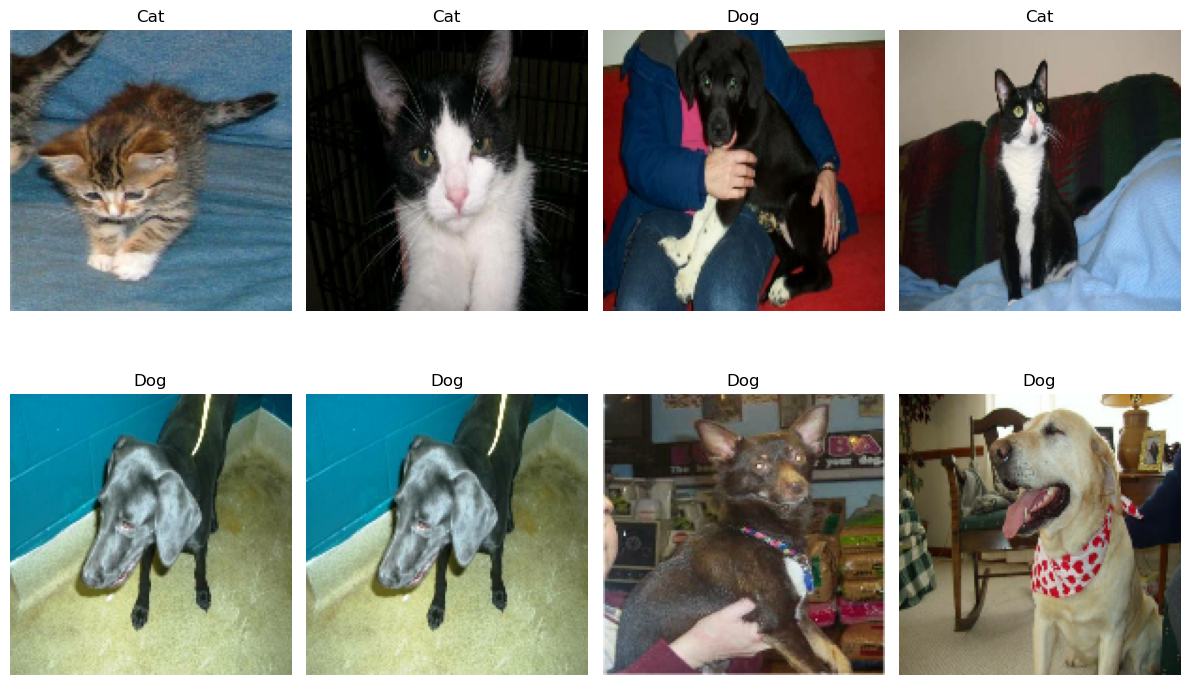

In [8]:
# 1. Define X (images) and y (labels) from a single batch of the dataset
X, y = next(iter(train_dataset))

# 2. Update the function to use X and y
def show_sample_images(X, y, num_images=8):
    plt.figure(figsize=(12, 8))
    for i in range(num_images):
        idx = np.random.randint(0, len(X))
        plt.subplot(2, 4, i + 1)
        
        # Convert the tensor to numpy and cast to uint8 for matplotlib
        plt.imshow(X[idx].numpy().astype("uint8")) 
        
        plt.title(f"{'Dog' if y[idx] == 1 else 'Cat'}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# 3. Call the function with your newly defined X and y
show_sample_images(X, y)

# Normalize and split data

In [ ]:
X = X.astype('float32') /255.0

# Split into train, validation, test sets (60-20-20), stratified so each
# split keep the same class balance as the full dataset.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y test_size = 0.4, random_state = SEED, stratify = y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = SEED, stratify = y_temp
)

print(f"Training: {len(X_train)} images (cats = {np.sum(y_train == 0)}, dogs = {np.sum(y_train == 1)})")